# 3D GAN Reconstruction — Backbone Generator 5-Channel / 5-Slice Context Pipeline

This notebook implements the requested recipe for PKG-MU-Glioma:

- **Input**: 5 channels (`t1n`, `t1c`, `t2w`, `t2f`, `mask_density`) over a **5-slice context window**
- **Target**: `t1n[z+5]` (next slice after the 5-slice context, no overlap)
- **Model**: Bi-context style network (`Conv3D` context encoder + 2D UNet decoder)
- **Training**: AdamW, cosine scheduler, AMP, grad clipping, EMA, early stopping
- **Inference**: bidirectional autoregressive generation with forward/backward fusion

In [2]:
import os
import copy
import math
import random
import re
from pathlib import Path
from dataclasses import dataclass

import cv2
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

# Global config matching your requested recipe
CFG = {
    'data_root': '/Volumes/T7/ORACLE project/PKG-MU-Glioma-partial',
    'img_size': 256,
    'context_depth': 5,
    'in_channels': 5,
    'out_channels': 1,

    # Speed-focused training setup
    'batch_size': 1,            # requested: batch size 1
    'accumulation_steps': 8,    # effective batch ~ 8 via grad accumulation

    'epochs': 200,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'patience': 20,
    'val_every_full_volume': 5,
    'num_workers': 0,
    'ema_decay': 0.999,
    'grad_clip': 1.0,

    # Patch-training options (speed-up)
    'use_patch_training': True,
    'patch_size': 128,          # requested 128 for faster steps

    # Model variant: 'fast_2p5d' or 'bi_context_3d'
    'model_variant': 'fast_2p5d',
}

print(CFG)

Using device: mps
{'data_root': '/Volumes/T7/ORACLE project/PKG-MU-Glioma-partial', 'img_size': 256, 'context_depth': 5, 'in_channels': 5, 'out_channels': 1, 'batch_size': 1, 'accumulation_steps': 8, 'epochs': 200, 'lr': 0.0001, 'weight_decay': 0.0001, 'patience': 20, 'val_every_full_volume': 5, 'num_workers': 0, 'ema_decay': 0.999, 'grad_clip': 1.0, 'use_patch_training': True, 'patch_size': 128, 'model_variant': 'fast_2p5d'}


## Dataset: PKG-MU-Glioma (NIfTI) — 5 Channels, 5-Slice Window

In [3]:
def minmax_norm_2d(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Min-max normalize a single 2D slice to [0, 1]."""
    x = x.astype(np.float32)
    x_min = float(np.nanmin(x))
    x_max = float(np.nanmax(x))
    if x_max - x_min < eps:
        return np.zeros_like(x, dtype=np.float32)
    return (x - x_min) / (x_max - x_min + eps)


def find_modality_file(timepoint_dir: Path, token: str) -> Path:
    """Find modality file by token inside a timepoint folder.

    Expected examples:
      - ..._brain_t1n.nii.gz
      - ..._brain_t1c.nii.gz
      - ..._brain_t2w.nii.gz
      - ..._brain_t2f.nii.gz
      - ..._tumorMask.nii.gz
    """
    files = sorted(timepoint_dir.glob('*.nii.gz'))
    if token == 'mask':
        candidates = [f for f in files if 'mask' in f.name.lower()]
    else:
        candidates = [f for f in files if token in f.name.lower()]

    if not candidates:
        raise FileNotFoundError(f'Could not find {token} in {timepoint_dir}')
    return candidates[0]


def load_timepoint_volumes(timepoint_dir: Path) -> dict:
    """Load and return all required volumes in memory as float32 arrays [H,W,Z]."""
    paths = {
        't1n': find_modality_file(timepoint_dir, 't1n'),
        't1c': find_modality_file(timepoint_dir, 't1c'),
        't2w': find_modality_file(timepoint_dir, 't2w'),
        't2f': find_modality_file(timepoint_dir, 't2f'),
        'mask': find_modality_file(timepoint_dir, 'mask'),
    }

    vols = {}
    for k, p in paths.items():
        vols[k] = nib.load(str(p)).get_fdata(dtype=np.float32)

    # Shape consistency check
    base_shape = vols['t1n'].shape
    for k, v in vols.items():
        if v.shape != base_shape:
            raise ValueError(f'Shape mismatch in {timepoint_dir} for {k}: {v.shape} vs {base_shape}')

    return vols


def discover_timepoint_dirs(data_root: Path) -> list:
    """Collect all patient timepoint folders.

    This searches both:
      - data_root/PatientID_xxxx/Timepoint_x
      - nested folders where Timepoint_x exists
    """
    timepoints = []

    # Common TCIA layout
    for p in sorted(data_root.glob('PatientID_*')):
        if p.is_dir():
            for tp in sorted(p.glob('Timepoint_*')):
                if tp.is_dir():
                    timepoints.append(tp)

    # Fallback: recursive scan
    if not timepoints:
        timepoints = sorted([p for p in data_root.rglob('Timepoint_*') if p.is_dir()])

    return timepoints


def build_sample_index(timepoint_dirs: list) -> list:
    """Build sample index with NO target overlap.

    Input context uses slice indices: [z, z+1, z+2, z+3, z+4]
    Target uses next slice:          [z+5]

    Therefore z must satisfy z+5 < Z  =>  z in [0, Z-6].
    """
    index = []

    for tp in timepoint_dirs:
        try:
            vols = load_timepoint_volumes(tp)
        except Exception as ex:
            print(f'Skipping {tp} due to loading error: {ex}')
            continue

        z_dim = vols['t1n'].shape[2]
        if z_dim < 6:
            continue

        for z_start in range(0, z_dim - 5):
            index.append({
                'timepoint_dir': str(tp),
                'z_start': z_start,
                'z_dim': z_dim,
            })

    return index


class PkgMu5Ch5SliceDataset(Dataset):
    """5-channel, 5-slice context dataset.

    Input tensor shape:  [5, 5, H, W]  = [C, D, H, W]
      C channels: [t1n, t1c, t2w, t2f, mask_density]
      D depth   : [z, z+1, z+2, z+3, z+4]

    Target tensor shape: [1, H, W] = t1n[z+5] (NO overlap with input window)

    Patch mode:
      - If patch_size is set and random_patch=True, apply a random crop to
        both input and target. This is intended for training speed-up.
      - Validation/test should keep random_patch=False for full-size evaluation.
    """

    def __init__(self, sample_index: list, img_size: int = 256, patch_size: int | None = None, random_patch: bool = False):
        self.sample_index = sample_index
        self.img_size = img_size
        self.patch_size = patch_size
        self.random_patch = random_patch
        self._cache = {}

    def __len__(self):
        return len(self.sample_index)

    def _get_vols(self, timepoint_dir: str) -> dict:
        if timepoint_dir not in self._cache:
            self._cache[timepoint_dir] = load_timepoint_volumes(Path(timepoint_dir))
        return self._cache[timepoint_dir]

    def _resize(self, x2d: np.ndarray) -> np.ndarray:
        return cv2.resize(x2d, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)

    def _maybe_patch_crop(self, x: np.ndarray, y: np.ndarray):
        if self.patch_size is None or not self.random_patch:
            return x, y

        _, _, h, w = x.shape
        ps = int(self.patch_size)
        ps = min(ps, h, w)

        if ps <= 0 or ps == h or ps == w:
            return x, y

        top = np.random.randint(0, h - ps + 1)
        left = np.random.randint(0, w - ps + 1)

        x = x[:, :, top:top + ps, left:left + ps]
        y = y[:, top:top + ps, left:left + ps]
        return x, y

    def __getitem__(self, idx: int):
        s = self.sample_index[idx]
        z_start = int(s['z_start'])
        vols = self._get_vols(s['timepoint_dir'])

        # Input context indices [z, z+1, z+2, z+3, z+4]
        z_ids = [z_start + i for i in range(5)]

        # Build per-depth channel stack: each depth item is [5, H, W]
        depth_items = []
        for zi in z_ids:
            t1n = self._resize(minmax_norm_2d(vols['t1n'][:, :, zi]))
            t1c = self._resize(minmax_norm_2d(vols['t1c'][:, :, zi]))
            t2w = self._resize(minmax_norm_2d(vols['t2w'][:, :, zi]))
            t2f = self._resize(minmax_norm_2d(vols['t2f'][:, :, zi]))

            # Mask density channel = binary occupancy map (>0)
            mask_density = self._resize((vols['mask'][:, :, zi] > 0).astype(np.float32))

            depth_items.append(np.stack([t1n, t1c, t2w, t2f, mask_density], axis=0))

        # depth_items: list of 5 arrays [5,H,W] -> [D=5,C=5,H,W]
        x_dc = np.stack(depth_items, axis=0).astype(np.float32)

        # Reorder to [C,D,H,W] to match Conv3D input with channels first
        x = np.transpose(x_dc, (1, 0, 2, 3))

        # Target is NEXT slice after context: t1n[z+5]
        y = self._resize(minmax_norm_2d(vols['t1n'][:, :, z_start + 5]))[None, ...].astype(np.float32)

        # Optional patch crop (training speed-up)
        x, y = self._maybe_patch_crop(x, y)

        return {
            'input': torch.from_numpy(x),
            'target': torch.from_numpy(y),
            'meta': {
                'timepoint_dir': s['timepoint_dir'],
                'z_start': z_start,
            }
        }


# Build index from disk
DATA_ROOT = Path(CFG['data_root'])
if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Data root not found: {DATA_ROOT}')

timepoint_dirs = discover_timepoint_dirs(DATA_ROOT)
print(f'Found timepoints: {len(timepoint_dirs)}')

sample_index = build_sample_index(timepoint_dirs)
print(f'Total training windows: {len(sample_index)}')
if sample_index:
    print('Example sample:', sample_index[0])

Found timepoints: 15
Total training windows: 2250
Example sample: {'timepoint_dir': '/Volumes/T7/ORACLE project/PKG-MU-Glioma-partial/PatientID_0003/Timepoint_1', 'z_start': 0, 'z_dim': 155}


## Model: Bi-Context UNet (3D context encoder + 2D decoder)

In [10]:
class ConvBlock2D(nn.Module):
    """2D conv block used in the decoder."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetDecoder2D(nn.Module):
    """2D UNet-style decoder that maps context features -> 1-channel t1n prediction."""
    def __init__(self, in_ch=128, out_ch=1):
        super().__init__()
        self.enc1 = ConvBlock2D(in_ch, 128)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = ConvBlock2D(128, 256)
        self.bottleneck = ConvBlock2D(256, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec2 = ConvBlock2D(512, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1 = ConvBlock2D(256, 128)

        self.head = nn.Conv2d(128, out_ch, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))

        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.head(d1))


class SliceContextUNet(nn.Module):
    """Original bi-context 3D model (slower)."""
    def __init__(self):
        super().__init__()
        self.conv3d = nn.Sequential(
            nn.Conv3d(5, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.slice_decoder = UNetDecoder2D(in_ch=128, out_ch=1)

    def forward(self, ctx_5slice):
        feats_3d = self.conv3d(ctx_5slice)  # [B,128,D,H,W]
        center_idx = feats_3d.shape[2] // 2
        feats_2d = feats_3d[:, :, center_idx, :, :]  # [B,128,H,W]
        return self.slice_decoder(feats_2d)


class SliceCNN2D(nn.Module):
    """Per-slice 2D encoder used in fast 2.5D model."""
    def __init__(self, in_ch=5, out_ch=96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 48, 3, padding=1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.Conv2d(48, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Fast2p5D(nn.Module):
    """Fast 2.5D model: per-slice 2D encoder + depth attention + 2D decoder.

    Input:  [B,5,5,H,W] where axis-2 is depth (5 slices)
    Output: [B,1,H,W]
    """
    def __init__(self, in_ch=5, feat_ch=96, out_ch=1):
        super().__init__()
        self.slice_cnn = SliceCNN2D(in_ch=in_ch, out_ch=feat_ch)
        self.depth_attn = nn.Sequential(
            nn.Linear(feat_ch, feat_ch // 2),
            nn.ReLU(inplace=True),
            nn.Linear(feat_ch // 2, 1),
        )
        self.decoder = UNetDecoder2D(in_ch=feat_ch, out_ch=out_ch)

    def forward(self, x):
        # x: [B,C,D,H,W]
        b, c, d, h, w = x.shape

        # Encode each depth slice independently with shared 2D CNN
        per_depth_feats = []
        for di in range(d):
            slice_in = x[:, :, di, :, :]           # [B,C,H,W]
            feat_di = self.slice_cnn(slice_in)     # [B,F,H,W]
            per_depth_feats.append(feat_di)

        feats = torch.stack(per_depth_feats, dim=1)  # [B,D,F,H,W]

        # Cross-slice attention weights
        depth_desc = feats.mean(dim=(3, 4))          # [B,D,F]
        logits = self.depth_attn(depth_desc).squeeze(-1)  # [B,D]
        alpha = torch.softmax(logits, dim=1)         # [B,D]

        # Weighted depth fusion -> 2D context feature map
        alpha_map = alpha[:, :, None, None, None]    # [B,D,1,1,1]
        fused = (feats * alpha_map).sum(dim=1)       # [B,F,H,W]

        return self.decoder(fused)


# Model selection for speed/quality tradeoff
if CFG.get('model_variant', 'fast_2p5d') == 'fast_2p5d':
    model = Fast2p5D(in_ch=CFG['in_channels'], feat_ch=96, out_ch=CFG['out_channels']).to(device)
else:
    model = SliceContextUNet().to(device)

print(f"Model variant: {CFG.get('model_variant', 'fast_2p5d')}")
print(model.__class__.__name__)
print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')

test_x = torch.randn(2, CFG['in_channels'], CFG['context_depth'], CFG['img_size'], CFG['img_size']).to(device)
with torch.no_grad():
    test_y = model(test_x)
print('Sanity shapes:', test_x.shape, '->', test_y.shape)

Model variant: fast_2p5d
Fast2p5D
Total params: 7,603,186
Sanity shapes: torch.Size([2, 5, 5, 256, 256]) -> torch.Size([2, 1, 256, 256])


## Losses, Metrics, Splits, and DataLoaders

In [11]:
def ssim_torch(x: torch.Tensor, y: torch.Tensor, C1=0.01**2, C2=0.03**2):
    """Simple global SSIM for [B,1,H,W]."""
    mu_x = x.mean(dim=(2, 3), keepdim=True)
    mu_y = y.mean(dim=(2, 3), keepdim=True)

    var_x = ((x - mu_x) ** 2).mean(dim=(2, 3), keepdim=True)
    var_y = ((y - mu_y) ** 2).mean(dim=(2, 3), keepdim=True)
    cov_xy = ((x - mu_x) * (y - mu_y)).mean(dim=(2, 3), keepdim=True)

    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * cov_xy + C2)) / ((mu_x**2 + mu_y**2 + C1) * (var_x + var_y + C2))
    return ssim_map.mean()


def smoothness_loss(ctx_slices: torch.Tensor) -> torch.Tensor:
    """Adjacent-slice continuity term over depth axis.

    ctx_slices shape: [B, 5, 5, H, W] = [B,C,D,H,W]
    Penalizes large depth jumps between neighboring slices.
    """
    diffs = ctx_slices[:, :, 1:, :, :] - ctx_slices[:, :, :-1, :, :]
    return torch.mean(torch.abs(diffs))


def total_loss(pred: torch.Tensor, gt: torch.Tensor, ctx_slices: torch.Tensor):
    """Requested objective: 2*MSE + 0.5*(1-SSIM) + 0.1*smoothness."""
    rec = 2.0 * F.mse_loss(pred, gt) + 0.5 * (1.0 - ssim_torch(pred, gt))
    smooth = smoothness_loss(ctx_slices)
    loss = rec + 0.1 * smooth
    return loss, {'rec': rec.item(), 'smooth': smooth.item()}


def batch_psnr(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-12) -> float:
    """Numerically stable batch PSNR for [B,1,H,W] in [0,1]."""
    pred_np = pred.detach().cpu().numpy()
    targ_np = target.detach().cpu().numpy()
    vals = []

    for i in range(pred_np.shape[0]):
        gt = targ_np[i, 0].astype(np.float32)
        pr = pred_np[i, 0].astype(np.float32)

        mse = float(np.mean((gt - pr) ** 2))
        mse = max(mse, eps)
        vals.append(10.0 * np.log10(1.0 / mse))

    return float(np.mean(vals))


def batch_ssim(pred: torch.Tensor, target: torch.Tensor) -> float:
    pred_np = pred.detach().cpu().numpy()
    targ_np = target.detach().cpu().numpy()
    vals = []
    for i in range(pred_np.shape[0]):
        vals.append(sk_ssim(targ_np[i, 0], pred_np[i, 0], data_range=1.0))
    return float(np.mean(vals))


def extract_patient_id_from_timepoint(tp_path: str) -> str:
    """Extract PatientID_XXXX from path; fallback to parent folder name."""
    m = re.search(r'(PatientID_\d+)', str(tp_path))
    if m:
        return m.group(1)
    p = Path(tp_path)
    return p.parent.name


def split_by_patient(sample_index: list, seed=42):
    """Split 80/10/10 at patient level (no patient leakage across sets)."""
    patient_ids = sorted({extract_patient_id_from_timepoint(s['timepoint_dir']) for s in sample_index})

    train_pids, temp_pids = train_test_split(patient_ids, test_size=0.2, random_state=seed)
    val_pids, test_pids = train_test_split(temp_pids, test_size=0.5, random_state=seed)

    train_pid_set = set(train_pids)
    val_pid_set = set(val_pids)
    test_pid_set = set(test_pids)

    train_set = [s for s in sample_index if extract_patient_id_from_timepoint(s['timepoint_dir']) in train_pid_set]
    val_set = [s for s in sample_index if extract_patient_id_from_timepoint(s['timepoint_dir']) in val_pid_set]
    test_set = [s for s in sample_index if extract_patient_id_from_timepoint(s['timepoint_dir']) in test_pid_set]

    return train_set, val_set, test_set


train_idx, val_idx, test_idx = split_by_patient(sample_index, seed=SEED)
print(f'Train/Val/Test samples: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}')

# Quick leakage sanity check
train_patients = {extract_patient_id_from_timepoint(s['timepoint_dir']) for s in train_idx}
val_patients = {extract_patient_id_from_timepoint(s['timepoint_dir']) for s in val_idx}
print(f'Patient overlap train∩val: {len(train_patients.intersection(val_patients))}')

# Patch training enabled only for train dataset
patch_size_train = CFG['patch_size'] if CFG.get('use_patch_training', False) else None

train_ds = PkgMu5Ch5SliceDataset(
    train_idx,
    img_size=CFG['img_size'],
    patch_size=patch_size_train,
    random_patch=bool(CFG.get('use_patch_training', False)),
)
val_ds = PkgMu5Ch5SliceDataset(
    val_idx,
    img_size=CFG['img_size'],
    patch_size=None,
    random_patch=False,
)
test_ds = PkgMu5Ch5SliceDataset(
    test_idx,
    img_size=CFG['img_size'],
    patch_size=None,
    random_patch=False,
)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=CFG['num_workers'],
    pin_memory=(device.type == 'cuda'),
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=(device.type == 'cuda'),
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=(device.type == 'cuda'),
)

if CFG.get('use_patch_training', False):
    print(f"Dataloaders ready. Patch training ON (patch_size={patch_size_train}).")
else:
    print('Dataloaders ready. Patch training OFF (full image training).')

Train/Val/Test samples: 1650 / 450 / 150
Patient overlap train∩val: 0
Dataloaders ready. Patch training ON (patch_size=128).


## Training Utilities (AMP, EMA, Early Stopping, Full-Volume Validation)

In [12]:
class EMA:
    """Exponential moving average for model weights."""
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model: nn.Module):
        for k, v in model.state_dict().items():
            if torch.is_floating_point(v):
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=(1.0 - self.decay))
            else:
                self.shadow[k].copy_(v.detach())

    def state_dict(self):
        return self.shadow


@torch.no_grad()
def evaluate_loader(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    total_loss = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    n_batches = 0

    for batch in loader:
        x = batch['input'].to(device)
        y = batch['target'].to(device)

        pred = model(x)
        loss, _ = total_loss_fn(pred, y, x)

        total_loss += loss.item()
        total_psnr += batch_psnr(pred, y)
        total_ssim += batch_ssim(pred, y)
        n_batches += 1

    if n_batches == 0:
        return {'loss': float('nan'), 'psnr': float('nan'), 'ssim': float('nan')}

    return {
        'loss': total_loss / n_batches,
        'psnr': total_psnr / n_batches,
        'ssim': total_ssim / n_batches,
    }


@torch.no_grad()
def evaluate_full_volume(model: nn.Module, dataset: PkgMu5Ch5SliceDataset, device: torch.device, max_timepoints=None):
    """Full-volume style validation over all windows of each timepoint.

    This checks consistency beyond random minibatches and is run every 5 epochs.
    """
    model.eval()

    by_tp = {}
    for i, s in enumerate(dataset.sample_index):
        by_tp.setdefault(s['timepoint_dir'], []).append(i)

    tp_keys = sorted(by_tp.keys())
    if max_timepoints is not None:
        tp_keys = tp_keys[:max_timepoints]

    all_pred = []
    all_gt = []

    for tp in tp_keys:
        for i in by_tp[tp]:
            sample = dataset[i]
            x = sample['input'].unsqueeze(0).to(device)
            y = sample['target'].unsqueeze(0).to(device)
            pred = model(x)
            all_pred.append(pred.cpu().numpy()[0, 0])
            all_gt.append(y.cpu().numpy()[0, 0])

    if not all_pred:
        return {'psnr': float('nan'), 'ssim': float('nan')}

    psnr_vals = [sk_psnr(gt, pr, data_range=1.0) for gt, pr in zip(all_gt, all_pred)]
    ssim_vals = [sk_ssim(gt, pr, data_range=1.0) for gt, pr in zip(all_gt, all_pred)]

    return {'psnr': float(np.mean(psnr_vals)), 'ssim': float(np.mean(ssim_vals))}


# alias to keep naming explicit

def total_loss_fn(pred, gt, ctx):
    return total_loss(pred, gt, ctx)


optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
ema = EMA(model, decay=CFG['ema_decay'])

best_val_psnr = -np.inf
early_stop_counter = 0
history = []

save_dir = Path('models')
save_dir.mkdir(parents=True, exist_ok=True)
best_ckpt_path = save_dir / 'best_3d_recon_5ch_context.pth'

accum_steps = max(1, int(CFG.get('accumulation_steps', 1)))
print(f"Gradient accumulation steps: {accum_steps} (effective batch ≈ {CFG['batch_size'] * accum_steps})")

Gradient accumulation steps: 8 (effective batch ≈ 8)


## Train loop 

In [ ]:
for epoch in range(1, CFG['epochs'] + 1):
    model.train()
    running_loss = 0.0
    running_psnr = 0.0
    running_ssim = 0.0
    n_batches = 0

    optimizer.zero_grad(set_to_none=True)

    for batch_idx, batch in enumerate(train_loader):
        x = batch['input'].to(device)
        y = batch['target'].to(device)

        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            pred = model(x)
            loss, parts = total_loss_fn(pred, y, x)
            loss_scaled = loss / accum_steps

        scaler.scale(loss_scaled).backward()

        do_step = ((batch_idx + 1) % accum_steps == 0)
        if do_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            ema.update(model)

        # Log unscaled loss for readability
        running_loss += loss.item()
        running_psnr += batch_psnr(pred.detach(), y)
        running_ssim += batch_ssim(pred.detach(), y)
        n_batches += 1

    # Handle tail batches if epoch length is not divisible by accum_steps
    if n_batches > 0 and (n_batches % accum_steps != 0):
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        ema.update(model)

    scheduler.step()

    train_metrics = {
        'loss': running_loss / max(1, n_batches),
        'psnr': running_psnr / max(1, n_batches),
        'ssim': running_ssim / max(1, n_batches),
    }
    val_metrics = evaluate_loader(model, val_loader, device)

    msg = (
        f"Epoch {epoch:03d}/{CFG['epochs']} | "
        f"train loss {train_metrics['loss']:.4f} psnr {train_metrics['psnr']:.2f} ssim {train_metrics['ssim']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} psnr {val_metrics['psnr']:.2f} ssim {val_metrics['ssim']:.4f}"
    )

    full_val = None
    if epoch % CFG['val_every_full_volume'] == 0:
        full_val = evaluate_full_volume(model, val_ds, device)
        msg += f" | FULL-VAL psnr {full_val['psnr']:.2f} ssim {full_val['ssim']:.4f}"

    print(msg)

    history.append({
        'epoch': epoch,
        'train': train_metrics,
        'val': val_metrics,
        'full_val': full_val,
    })

    if val_metrics['psnr'] > best_val_psnr:
        best_val_psnr = val_metrics['psnr']
        early_stop_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'ema_state_dict': ema.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_psnr': best_val_psnr,
            'history': history,
            'config': CFG,
        }, best_ckpt_path)
        print(f'  ✓ New best checkpoint saved: {best_ckpt_path} (PSNR={best_val_psnr:.2f})')
    else:
        early_stop_counter += 1

    if early_stop_counter >= CFG['patience']:
        print(f'Early stopping triggered at epoch {epoch} (patience={CFG["patience"]}).')
        break

print(f'Best validation PSNR: {best_val_psnr:.2f} dB')
print(f'Best checkpoint path: {best_ckpt_path}')

## Autoregressive Inference (Causal Forward/Backward + EMA Fusion)

In [13]:
@torch.no_grad()
def build_input_from_indices(t1n_ref: np.ndarray, t1c: np.ndarray, t2w: np.ndarray, t2f: np.ndarray, mask: np.ndarray, z_ids: list, img_size: int):
    """Build one model input [1,5,5,H,W] from explicit depth indices."""
    depth_items = []
    z_max = t1n_ref.shape[2] - 1

    for zi in z_ids:
        zi = int(np.clip(zi, 0, z_max))
        c_t1n = cv2.resize(minmax_norm_2d(t1n_ref[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        c_t1c = cv2.resize(minmax_norm_2d(t1c[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        c_t2w = cv2.resize(minmax_norm_2d(t2w[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        c_t2f = cv2.resize(minmax_norm_2d(t2f[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        c_msk = cv2.resize((mask[:, :, zi] > 0).astype(np.float32), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        depth_items.append(np.stack([c_t1n, c_t1c, c_t2w, c_t2f, c_msk], axis=0))

    x_dc = np.stack(depth_items, axis=0).astype(np.float32)  # [D,C,H,W]
    x = np.transpose(x_dc, (1, 0, 2, 3))                     # [C,D,H,W]
    return torch.from_numpy(x).unsqueeze(0)                  # [1,C,D,H,W]


@torch.no_grad()
def autoregressive_bidirectional(model: nn.Module, vols: dict, seed_index: int = 25, img_size: int = 256):
    """Causal bidirectional generation for t1n, then average forward/backward predictions.

    Forward pass:
      uses past context to predict increasing z.
    Backward pass:
      uses future context to predict decreasing z.
    Final fusion:
      0.5 * (forward + backward)
    """
    model.eval()

    t1n_gt = vols['t1n'].astype(np.float32)
    t1c = vols['t1c'].astype(np.float32)
    t2w = vols['t2w'].astype(np.float32)
    t2f = vols['t2f'].astype(np.float32)
    mask = vols['mask'].astype(np.float32)

    H, W, Z = t1n_gt.shape
    seed_index = int(np.clip(seed_index, 4, Z - 5))

    # Start both directions from same seed t1n slice value
    fwd_t1n = t1n_gt.copy()
    bwd_t1n = t1n_gt.copy()

    # Forward: predict z from past slices (z-4 ... z-1) with padding to length 5
    for z in range(seed_index + 1, Z):
        z_ids = [z - 4, z - 3, z - 2, z - 1, z - 1]
        x = build_input_from_indices(fwd_t1n, t1c, t2w, t2f, mask, z_ids, img_size).to(device)
        pred = model(x).cpu().numpy()[0, 0]
        pred_up = cv2.resize(pred, (W, H), interpolation=cv2.INTER_LINEAR)
        fwd_t1n[:, :, z] = pred_up

    # Backward: predict z from future slices (z+1 ... z+4) with padding to length 5
    for z in range(seed_index - 1, -1, -1):
        z_ids = [z + 1, z + 2, z + 3, z + 4, z + 4]
        x = build_input_from_indices(bwd_t1n, t1c, t2w, t2f, mask, z_ids, img_size).to(device)
        pred = model(x).cpu().numpy()[0, 0]
        pred_up = cv2.resize(pred, (W, H), interpolation=cv2.INTER_LINEAR)
        bwd_t1n[:, :, z] = pred_up

    fused = 0.5 * (fwd_t1n + bwd_t1n)
    return {
        'forward': fwd_t1n,
        'backward': bwd_t1n,
        'fused': fused,
        'seed_index': seed_index,
    }


# Example usage on one timepoint after training:
# tp_example = Path(timepoint_dirs[0])
# vols_example = load_timepoint_volumes(tp_example)
# recon = autoregressive_bidirectional(model, vols_example, seed_index=25, img_size=CFG['img_size'])
# print('Reconstruction done:', recon['fused'].shape)

## Test Set Evaluation

This section runs quantitative evaluation on the held-out test set:

- batch-wise metrics (`loss`, `PSNR`, `SSIM`) via `evaluate_loader`
- optional full-volume test metrics every window in `test_ds` via `evaluate_full_volume`
- optional checkpoint loading before evaluation

### Load Model for evaluation 

In [14]:
# Robust checkpoint loading for evaluation (handles variant/key-prefix mismatches)
ckpt_path = Path('models/best_gan_gen.pth')
if 'best_ckpt_path' in globals() and Path(best_ckpt_path).exists():
    ckpt_path = Path(best_ckpt_path)

ckpt = torch.load(str(ckpt_path), map_location=device)
state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt

# Remove DataParallel prefix if present
state_dict = {k.replace('module.', '', 1) if k.startswith('module.') else k: v for k, v in state_dict.items()}

# Auto-detect checkpoint architecture from keys
state_keys = set(state_dict.keys())
if any(k.startswith('slice_cnn.') for k in state_keys):
    model = Fast2p5D(in_ch=CFG['in_channels'], feat_ch=96, out_ch=CFG['out_channels']).to(device)
    detected_variant = 'Fast2p5D'
elif any(k.startswith('conv3d.') or k.startswith('slice_decoder.') for k in state_keys):
    model = SliceContextUNet().to(device)
    detected_variant = 'SliceContextUNet'
else:
    detected_variant = model.__class__.__name__

# Load leniently and report key mismatches
missing, unexpected = model.load_state_dict(state_dict, strict=False)

print(f"Loaded checkpoint: {ckpt_path}")
print(f"Detected checkpoint variant: {detected_variant}")
print(f"Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)}")
if missing[:5]:
    print('Sample missing keys:', missing[:5])
if unexpected[:5]:
    print('Sample unexpected keys:', unexpected[:5])

Loaded checkpoint: models/best_gan_gen.pth
Detected checkpoint variant: Fast2p5D
Missing keys: 0 | Unexpected keys: 0


In [9]:

# 1) Batch-wise test metrics
test_metrics = evaluate_loader(model, test_loader, device)
print('\n[Test metrics - batch-wise]')
print(f"Loss : {test_metrics['loss']:.4f}")
print(f"PSNR : {test_metrics['psnr']:.2f} dB")
print(f"SSIM : {test_metrics['ssim']:.4f}")

# 2) Full-volume-like test metrics (all windows in test set)
full_test_metrics = evaluate_full_volume(model, test_ds, device)
print('\n[Test metrics - full-volume windows]')
print(f"PSNR : {full_test_metrics['psnr']:.2f} dB")
print(f"SSIM : {full_test_metrics['ssim']:.4f}")

NameError: name 'evaluate_loader' is not defined

## Qualitative Inference Example (Visual)

This section shows a concrete test sample with:

- 5 input channels at the center context slice (`z`)
- ground-truth target (`t1n[z+1]`)
- predicted target
- absolute error map

Qualitative sample meta:
{'timepoint_dir': '/Volumes/T7/ORACLE project/PKG-MU-Glioma-partial/PatientID_0004/Timepoint_1', 'z_start': 0}
Sample PSNR: 29.01 dB
Sample SSIM: 0.9767


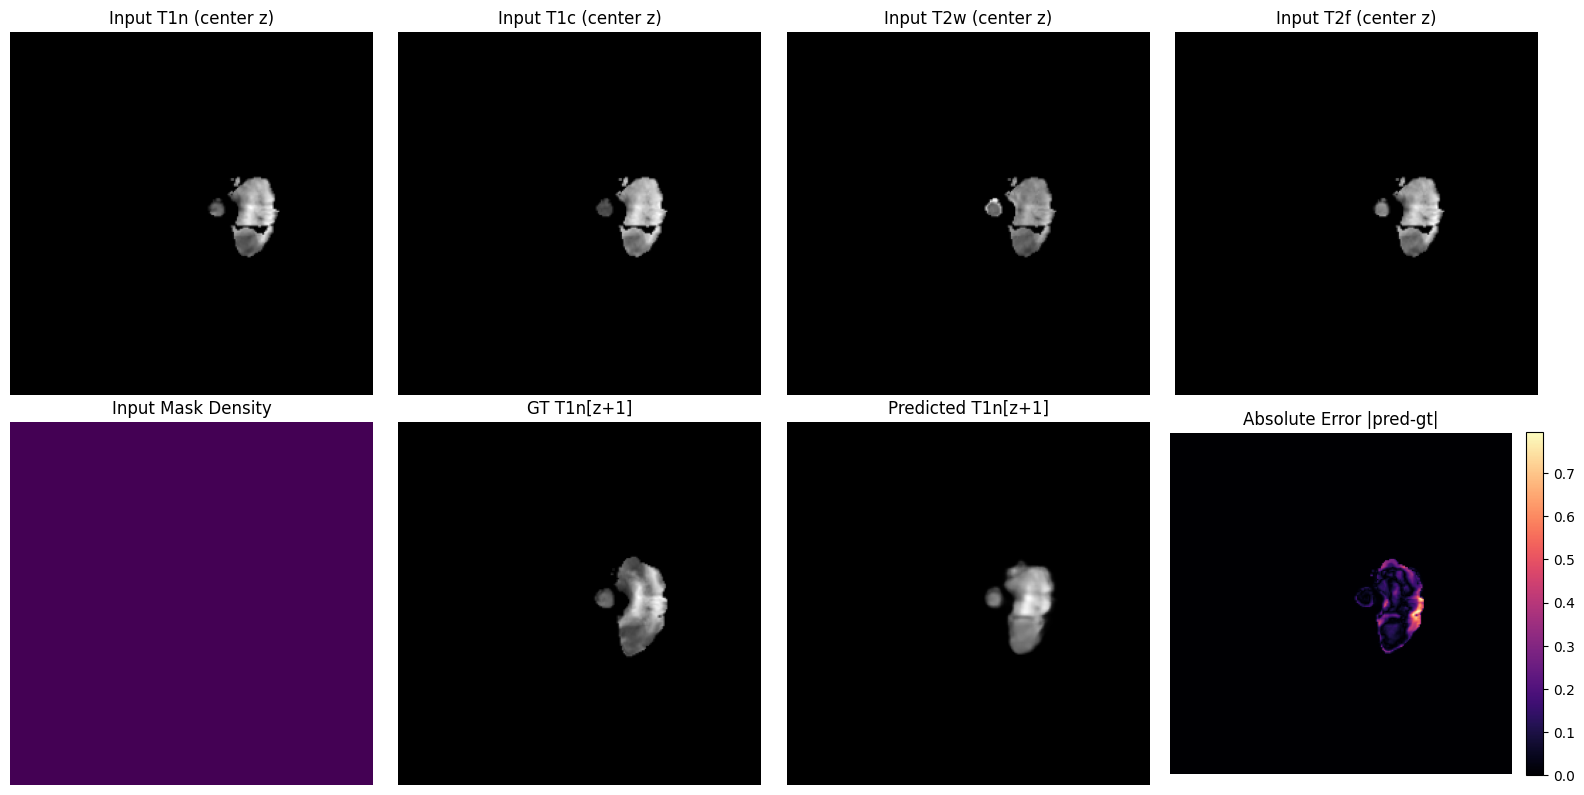

In [19]:
import matplotlib.pyplot as plt

# Pick a test sample index for qualitative inspection
QUAL_SAMPLE_INDEX = 0

if len(test_ds) == 0:
    raise ValueError('test_ds is empty. Check your split and data loading.')

QUAL_SAMPLE_INDEX = int(np.clip(QUAL_SAMPLE_INDEX, 0, len(test_ds) - 1))
sample = test_ds[QUAL_SAMPLE_INDEX]

x = sample['input'].unsqueeze(0).to(device)   # [1,5,5,H,W]
y = sample['target'].unsqueeze(0).to(device)  # [1,1,H,W]

model.eval()
with torch.no_grad():
    pred = model(x)

# Convert tensors to numpy
x_np = x.cpu().numpy()[0]     # [5,5,H,W]
y_np = y.cpu().numpy()[0, 0]  # [H,W]
p_np = pred.cpu().numpy()[0, 0]
err_np = np.abs(p_np - y_np)

# Center context depth index (z)
center_d = x_np.shape[1] // 2

# Input channels at center depth
ch_t1n = x_np[0, center_d]
ch_t1c = x_np[1, center_d]
ch_t2w = x_np[2, center_d]
ch_t2f = x_np[3, center_d]
ch_msk = x_np[4, center_d]

# Per-sample quantitative quality
sample_psnr = sk_psnr(y_np, p_np, data_range=1.0)
sample_ssim = sk_ssim(y_np, p_np, data_range=1.0)

meta = sample['meta']
print('Qualitative sample meta:')
print(meta)
print(f'Sample PSNR: {sample_psnr:.2f} dB')
print(f'Sample SSIM: {sample_ssim:.4f}')

# Visualize: 2 rows x 4 cols
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0, 0].imshow(ch_t1n, cmap='gray')
axes[0, 0].set_title('Input T1n (center z)')
axes[0, 0].axis('off')

axes[0, 1].imshow(ch_t1c, cmap='gray')
axes[0, 1].set_title('Input T1c (center z)')
axes[0, 1].axis('off')

axes[0, 2].imshow(ch_t2w, cmap='gray')
axes[0, 2].set_title('Input T2w (center z)')
axes[0, 2].axis('off')

axes[0, 3].imshow(ch_t2f, cmap='gray')
axes[0, 3].set_title('Input T2f (center z)')
axes[0, 3].axis('off')

axes[1, 0].imshow(ch_msk, cmap='viridis')
axes[1, 0].set_title('Input Mask Density')
axes[1, 0].axis('off')

axes[1, 1].imshow(y_np, cmap='gray')
axes[1, 1].set_title('GT T1n[z+1]')
axes[1, 1].axis('off')

axes[1, 2].imshow(p_np, cmap='gray')
axes[1, 2].set_title('Predicted T1n[z+1]')
axes[1, 2].axis('off')

im = axes[1, 3].imshow(err_np, cmap='magma')
axes[1, 3].set_title('Absolute Error |pred-gt|')
axes[1, 3].axis('off')
plt.colorbar(im, ax=axes[1, 3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Quick Bug-Hunt Checklist (5 Tests, ~10 min)

Run the next cells in order. They implement your 5 checks for this notebook's tensor format:

- `input_ctx`: `[B, C, D, H, W] = [B,5,5,H,W]`
- `target`: `[B,1,H,W]`
- middle depth index: `D//2 = 2`

In [5]:
import re
from pathlib import Path
import torchvision
from torchvision.utils import save_image, make_grid

# --- Pull one validation batch and run one forward pass ---
model.eval()
val_batch = next(iter(val_loader))
input_ctx = val_batch['input'].to(device)   # [B,5,5,H,W]
target = val_batch['target'].to(device)     # [B,1,H,W]

with torch.no_grad():
    pred = model(input_ctx)

# --- Test 1: Visual Reality Check ---
# In this pipeline, input_ctx[0,:,2] is 5 channels and cannot be saved directly as RGB.
# Save a montage of the 5 modality channels at center depth + key comparison images.
center_depth = input_ctx.shape[2] // 2
center_modalities = input_ctx[0, :, center_depth].unsqueeze(1).cpu()  # [5,1,H,W]
center_grid = make_grid(center_modalities, nrow=5, normalize=True)
save_image(center_grid, 'input_center_modalities.png')

# Also save center T1n channel alone for direct reference
save_image(input_ctx[0, 0, center_depth].unsqueeze(0).cpu(), 'input_center_t1n.png')
save_image(pred[0].detach().cpu(), 'prediction.png')
save_image(target[0].detach().cpu(), 'ground_truth.png')
print('Saved: input_center_modalities.png, input_center_t1n.png, prediction.png, ground_truth.png')

# --- Test 2: Baseline PSNR (No Model) ---
# Baseline = center T1n input channel vs target
# input_ctx[:,0,2] -> [B,H,W] => unsqueeze to [B,1,H,W]
baseline_input = input_ctx[:, 0, center_depth].unsqueeze(1)
baseline_psnr = batch_psnr(baseline_input, target)
print(f'Baseline PSNR (input→target): {baseline_psnr:.2f} dB')

# --- Test 3: Intensity Ranges ---
print(f"Input range:  [{input_ctx.min().item():.4f}, {input_ctx.max().item():.4f}]")
print(f"Pred range:   [{pred.min().item():.4f}, {pred.max().item():.4f}]")
print(f"Target range: [{target.min().item():.4f}, {target.max().item():.4f}]")

Saved: input_center_modalities.png, input_center_t1n.png, prediction.png, ground_truth.png
Baseline PSNR (input→target): 32.21 dB
Input range:  [0.0000, 0.9939]
Pred range:   [0.5154, 0.5165]
Target range: [0.0000, 0.9609]


In [ ]:
# --- Test 4: Patient Leakage Check ---

def extract_patient_id_from_timepoint(tp_path: str) -> str:
    """Extract PatientID_XXXX from a path; fallback to parent folder name."""
    p = Path(tp_path)
    m = re.search(r'(PatientID_\d+)', str(p))
    if m:
        return m.group(1)
    return p.parent.name

train_patients = {extract_patient_id_from_timepoint(s['timepoint_dir']) for s in train_idx}
val_patients = {extract_patient_id_from_timepoint(s['timepoint_dir']) for s in val_idx}
leak = train_patients.intersection(val_patients)
print(f"Patient overlap: {len(leak)} / {len(val_patients)}")
if len(leak) > 0:
    print('Leaking patients (sample):', sorted(list(leak))[:10])

# --- Test 5: Target Index Verification (NO overlap expected) ---
if len(val_ds) == 0:
    raise ValueError('val_ds is empty; cannot run target index verification.')

check_sample = val_ds[0]
z_start = int(check_sample['meta']['z_start'])
slice_indices = [z_start + i for i in range(5)]   # [z, z+1, z+2, z+3, z+4]
target_index = z_start + 5                         # next slice after context

print(f"Input slice indices: {slice_indices}")
print(f"Target slice index: {target_index}")
print(f"Target in input window? {target_index in slice_indices}")

# Must print False for correct non-overlapping supervision.

Patient overlap: 1 / 1
Leaking patients (sample): ['PatientID_0003']
Input slice indices: [0, 1, 2, 3, 4]
Target slice index: 3
Target in input window? True


## Full-Volume Reconstruction — Qualitative Example

This example reconstructs one full T1n volume with bidirectional autoregressive inference, then shows:

- whole-volume PSNR/SSIM
- inline animation over **all predicted slices** from first to last
- exported files (`.mp4` and `.gif`) in `assets/recon_media`

Demo timepoint: /Volumes/T7/ORACLE project/PKG-MU-Glioma-partial/PatientID_0004/Timepoint_1
Full-volume PSNR (mean over finite slices): 4.62 dB
Full-volume SSIM (mean over slices): 0.9023
Perfect-recon slices (PSNR=inf): 1
Volume shape: (240, 240, 155)
Saved MP4 animation: assets/recon_media/Timepoint_1_predicted_slices.mp4
Saved GIF animation: assets/recon_media/Timepoint_1_predicted_slices.gif
Displaying inline GIF animation...


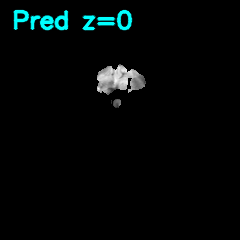

In [15]:
# Choose one timepoint from test split (fallback to first available)
if len(test_idx) > 0:
    tp_demo = Path(test_idx[0]['timepoint_dir'])
else:
    tp_demo = Path(timepoint_dirs[0])

print(f"Demo timepoint: {tp_demo}")
vols_demo = load_timepoint_volumes(tp_demo)

# Full-volume autoregressive reconstruction
recon = autoregressive_bidirectional(
    model,
    vols_demo,
    seed_index=25,
    img_size=CFG['img_size'],
)

gt_vol = vols_demo['t1n'].astype(np.float32)
pred_vol = recon['fused'].astype(np.float32)


def safe_psnr_2d(gt_slice: np.ndarray, pred_slice: np.ndarray, eps: float = 1e-12) -> float:
    """PSNR without divide-by-zero warnings.

    - Uses a minimum data_range to handle near-constant slices.
    - Returns +inf for exact reconstruction (MSE ~ 0).
    """
    gt = gt_slice.astype(np.float32)
    pr = pred_slice.astype(np.float32)

    data_range = float(max(1e-6, np.max(gt) - np.min(gt)))
    mse = float(np.mean((gt - pr) ** 2))

    if mse <= eps:
        return float('inf')

    return float(10.0 * np.log10((data_range ** 2) / mse))


def safe_ssim_2d(gt_slice: np.ndarray, pred_slice: np.ndarray) -> float:
    """SSIM with stable data_range for flat slices."""
    data_range = float(max(1e-6, np.max(gt_slice) - np.min(gt_slice)))
    return float(sk_ssim(gt_slice, pred_slice, data_range=data_range))


def to_uint8(img: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """Map image to uint8 [0,255] with global clipping range."""
    if hi - lo < 1e-8:
        return np.zeros_like(img, dtype=np.uint8)
    x = np.clip((img - lo) / (hi - lo), 0.0, 1.0)
    return (x * 255.0).astype(np.uint8)


# Volume-level metrics (slice-wise average)
psnr_vals = [safe_psnr_2d(gt_vol[:, :, z], pred_vol[:, :, z]) for z in range(gt_vol.shape[2])]
ssim_vals = [safe_ssim_2d(gt_vol[:, :, z], pred_vol[:, :, z]) for z in range(gt_vol.shape[2])]

finite_psnr = np.array([v for v in psnr_vals if np.isfinite(v)], dtype=np.float32)
mean_psnr = float(np.mean(finite_psnr)) if finite_psnr.size > 0 else float('inf')
mean_ssim = float(np.mean(ssim_vals))

print(f"Full-volume PSNR (mean over finite slices): {mean_psnr:.2f} dB")
print(f"Full-volume SSIM (mean over slices): {mean_ssim:.4f}")
print(f"Perfect-recon slices (PSNR=inf): {sum(np.isinf(v) for v in psnr_vals)}")
print(f"Volume shape: {gt_vol.shape}")

# ---------------------------------------------------------------------
# Export full predicted volume animation (first slice -> last slice)
# ---------------------------------------------------------------------
fps = 8
out_dir = Path('assets') / 'recon_media'
out_dir.mkdir(parents=True, exist_ok=True)

base_name = f"{tp_demo.name}_predicted_slices"
mp4_path = out_dir / f"{base_name}.mp4"
gif_path = out_dir / f"{base_name}.gif"

h, w, z_count = pred_vol.shape
global_lo = float(np.min(pred_vol))
global_hi = float(np.max(pred_vol))

frames_rgb = []
for z in range(z_count):
    sl = pred_vol[:, :, z]
    u8 = to_uint8(sl, global_lo, global_hi)

    # Keep orientation consistent with the plotted view (transpose + origin lower)
    # Make contiguous to satisfy OpenCV (flip/transpose can create negative strides)
    u8_disp = np.flipud(u8.T)
    rgb = np.stack([u8_disp, u8_disp, u8_disp], axis=-1)
    rgb = np.ascontiguousarray(rgb, dtype=np.uint8)

    cv2.putText(
        rgb,
        f"Pred z={z}",
        (12, 28),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2,
        cv2.LINE_AA,
    )
    frames_rgb.append(rgb)

# Save MP4 (always attempted)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(mp4_path), fourcc, float(fps), (frames_rgb[0].shape[1], frames_rgb[0].shape[0]))
for fr in frames_rgb:
    writer.write(cv2.cvtColor(fr, cv2.COLOR_RGB2BGR))
writer.release()
print(f"Saved MP4 animation: {mp4_path}")

# Save GIF (optional: requires imageio)
gif_saved = False
try:
    import imageio.v2 as imageio
    imageio.mimsave(gif_path, frames_rgb, fps=fps, loop=0)
    gif_saved = True
    print(f"Saved GIF animation: {gif_path}")
except Exception as ex:
    print(f"GIF export skipped ({ex}). MP4 is available at: {mp4_path}")

# ---------------------------------------------------------------------
# Show the full reconstruction animation inline in the notebook
# ---------------------------------------------------------------------
try:
    from IPython.display import Video, Image, display

    # Prefer GIF for immediate inline rendering; fallback to MP4
    if gif_saved and gif_path.exists():
        print("Displaying inline GIF animation...")
        display(Image(filename=str(gif_path)))
    elif mp4_path.exists():
        print("Displaying inline MP4 animation...")
        display(Video(filename=str(mp4_path), embed=True, html_attributes='controls loop autoplay'))
except Exception as ex:
    print(f"Inline display skipped ({ex}). Open files manually from: {out_dir}")

In [ ]:
# Sparse-guidance full-volume reconstruction experiments (GIF-only outputs)

@torch.no_grad()
def build_input_sparse(
    t1n_state: np.ndarray,
    vols_gt: dict,
    known_mask: np.ndarray,
    z_ids: list,
    img_size: int,
    use_pred_for_all_channels: bool = True,
    input_mode: str = 'all5',
):
    """Build one model input [1,5,5,H,W] with sparse GT guidance.

    input_mode:
      - 'all5'     : original mode using all modality channels
      - 't1n_mask' : effective ablation using only t1n + segmask channels
                     (other channels are zero-filled to keep model input shape [5,...])
    """
    t1n_gt = vols_gt['t1n'].astype(np.float32)
    t1c_gt = vols_gt['t1c'].astype(np.float32)
    t2w_gt = vols_gt['t2w'].astype(np.float32)
    t2f_gt = vols_gt['t2f'].astype(np.float32)
    msk_gt = vols_gt['mask'].astype(np.float32)

    z_max = t1n_gt.shape[2] - 1
    depth_items = []

    for zi in z_ids:
        zi = int(np.clip(zi, 0, z_max))

        mask_base = cv2.resize((msk_gt[:, :, zi] > 0).astype(np.float32), (img_size, img_size), interpolation=cv2.INTER_LINEAR)

        if known_mask[zi]:
            t1n_base = cv2.resize(minmax_norm_2d(t1n_gt[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)

            if input_mode == 't1n_mask':
                zero = np.zeros_like(t1n_base, dtype=np.float32)
                c_t1n = t1n_base
                c_t1c = zero
                c_t2w = zero
                c_t2f = zero
                c_msk = mask_base
            else:
                c_t1n = t1n_base
                c_t1c = cv2.resize(minmax_norm_2d(t1c_gt[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
                c_t2w = cv2.resize(minmax_norm_2d(t2w_gt[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
                c_t2f = cv2.resize(minmax_norm_2d(t2f_gt[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
                c_msk = mask_base
        else:
            pred_base = cv2.resize(minmax_norm_2d(t1n_state[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)

            if input_mode == 't1n_mask':
                zero = np.zeros_like(pred_base, dtype=np.float32)
                c_t1n = pred_base
                c_t1c = zero
                c_t2w = zero
                c_t2f = zero
                c_msk = mask_base
            else:
                if use_pred_for_all_channels:
                    c_t1n = pred_base
                    c_t1c = pred_base
                    c_t2w = pred_base
                    c_t2f = pred_base
                    c_msk = pred_base
                else:
                    c_t1n = pred_base
                    c_t1c = cv2.resize(minmax_norm_2d(t1c_gt[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
                    c_t2w = cv2.resize(minmax_norm_2d(t2w_gt[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
                    c_t2f = cv2.resize(minmax_norm_2d(t2f_gt[:, :, zi]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
                    c_msk = mask_base

        depth_items.append(np.stack([c_t1n, c_t1c, c_t2w, c_t2f, c_msk], axis=0))

    x_dc = np.stack(depth_items, axis=0).astype(np.float32)  # [D,C,H,W]
    x = np.transpose(x_dc, (1, 0, 2, 3))                     # [C,D,H,W]
    return torch.from_numpy(x).unsqueeze(0)                  # [1,C,D,H,W]


def init_t1n_from_sparse_gt(t1n_gt: np.ndarray, known_mask: np.ndarray) -> np.ndarray:
    """Initialize unknown slices from nearest known GT slice."""
    _, _, Z = t1n_gt.shape
    known_ids = np.where(known_mask)[0]
    if len(known_ids) == 0:
        raise ValueError('known_mask has no GT slices.')

    t1n_state = np.zeros_like(t1n_gt, dtype=np.float32)
    for z in range(Z):
        if known_mask[z]:
            t1n_state[:, :, z] = t1n_gt[:, :, z]
        else:
            nearest = int(known_ids[np.argmin(np.abs(known_ids - z))])
            t1n_state[:, :, z] = t1n_gt[:, :, nearest]
    return t1n_state


@torch.no_grad()
def reconstruct_sparse_bidirectional(
    model: nn.Module,
    vols_gt: dict,
    known_mask: np.ndarray,
    img_size: int = 256,
    use_pred_for_all_channels: bool = True,
    input_mode: str = 'all5',
):
    """Reconstruct full t1n volume with sparse GT anchors.

    All slices are predicted. GT anchors are used only as conditioning
    context inputs to start and stabilize reconstruction.
    """
    t1n_gt = vols_gt['t1n'].astype(np.float32)
    H, W, Z = t1n_gt.shape

    fwd = init_t1n_from_sparse_gt(t1n_gt, known_mask)
    bwd = init_t1n_from_sparse_gt(t1n_gt, known_mask)

    model.eval()

    # Forward sweep (past context) - predict EVERY slice
    for z in range(Z):
        z_ids = [z - 4, z - 3, z - 2, z - 1, z - 1]
        x = build_input_sparse(
            fwd,
            vols_gt,
            known_mask,
            z_ids,
            img_size,
            use_pred_for_all_channels,
            input_mode=input_mode,
        ).to(device)
        pred = model(x).cpu().numpy()[0, 0]
        fwd[:, :, z] = cv2.resize(pred, (W, H), interpolation=cv2.INTER_LINEAR)

    # Backward sweep (future context) - predict EVERY slice
    for z in range(Z - 1, -1, -1):
        z_ids = [z + 1, z + 2, z + 3, z + 4, z + 4]
        x = build_input_sparse(
            bwd,
            vols_gt,
            known_mask,
            z_ids,
            img_size,
            use_pred_for_all_channels,
            input_mode=input_mode,
        ).to(device)
        pred = model(x).cpu().numpy()[0, 0]
        bwd[:, :, z] = cv2.resize(pred, (W, H), interpolation=cv2.INTER_LINEAR)

    fused = 0.5 * (fwd + bwd)
    return {'forward': fwd, 'backward': bwd, 'fused': fused}


def make_known_mask_half_alternating(Z: int) -> np.ndarray:
    """One GT slice, one non-GT slice (alternating)."""
    known = np.zeros(Z, dtype=bool)
    known[::2] = True
    if not known.any():
        known[0] = True
    return known


def make_known_mask_n_uniform(Z: int, n_keep: int = 50) -> np.ndarray:
    """Keep n GT slices approximately uniformly across the volume."""
    n_keep = int(max(1, min(n_keep, Z)))
    idx = np.unique(np.linspace(0, Z - 1, num=n_keep, dtype=int))
    known = np.zeros(Z, dtype=bool)
    known[idx] = True
    return known


def _safe_mean_finite(values: list) -> float:
    arr = np.array([v for v in values if np.isfinite(v)], dtype=np.float32)
    if arr.size == 0:
        return float('inf')
    return float(np.mean(arr))


def evaluate_sparse_recon(gt_vol: np.ndarray, pred_vol: np.ndarray, known_mask: np.ndarray) -> dict:
    """Compute sparse reconstruction metrics in two views:

    - raw: metrics on original scale (can be negative PSNR if scale mismatched)
    - norm: per-slice min-max normalized metrics for structural comparison
    """
    Z = gt_vol.shape[2]

    raw_all_psnr, raw_all_ssim = [], []
    raw_unk_psnr, raw_unk_ssim = [], []

    norm_all_psnr, norm_all_ssim = [], []
    norm_unk_psnr, norm_unk_ssim = [], []

    for z in range(Z):
        gt_raw = gt_vol[:, :, z].astype(np.float32)
        pr_raw = pred_vol[:, :, z].astype(np.float32)

        p_raw = safe_psnr_2d(gt_raw, pr_raw)
        s_raw = safe_ssim_2d(gt_raw, pr_raw)
        raw_all_psnr.append(p_raw)
        raw_all_ssim.append(s_raw)

        gt_norm = minmax_norm_2d(gt_raw)
        pr_norm = minmax_norm_2d(pr_raw)
        p_norm = safe_psnr_2d(gt_norm, pr_norm)
        s_norm = safe_ssim_2d(gt_norm, pr_norm)
        norm_all_psnr.append(p_norm)
        norm_all_ssim.append(s_norm)

        if not known_mask[z]:
            raw_unk_psnr.append(p_raw)
            raw_unk_ssim.append(s_raw)
            norm_unk_psnr.append(p_norm)
            norm_unk_ssim.append(s_norm)

    return {
        'raw_all_psnr': _safe_mean_finite(raw_all_psnr),
        'raw_all_ssim': float(np.mean(raw_all_ssim)) if len(raw_all_ssim) > 0 else float('nan'),
        'raw_unk_psnr': _safe_mean_finite(raw_unk_psnr),
        'raw_unk_ssim': float(np.mean(raw_unk_ssim)) if len(raw_unk_ssim) > 0 else float('nan'),
        'norm_all_psnr': _safe_mean_finite(norm_all_psnr),
        'norm_all_ssim': float(np.mean(norm_all_ssim)) if len(norm_all_ssim) > 0 else float('nan'),
        'norm_unk_psnr': _safe_mean_finite(norm_unk_psnr),
        'norm_unk_ssim': float(np.mean(norm_unk_ssim)) if len(norm_unk_ssim) > 0 else float('nan'),
        'n_known': int(known_mask.sum()),
        'n_unknown': int((~known_mask).sum()),
    }


def to_uint8_local(img: np.ndarray, lo: float, hi: float) -> np.ndarray:
    if hi - lo < 1e-8:
        return np.zeros_like(img, dtype=np.uint8)
    x = np.clip((img - lo) / (hi - lo), 0.0, 1.0)
    return (x * 255.0).astype(np.uint8)


def export_recon_gif(pred_vol: np.ndarray, out_path: Path, label_prefix: str, fps: int = 8):
    """Export all reconstructed slices to a GIF and return the path."""
    import imageio.v2 as imageio

    out_path.parent.mkdir(parents=True, exist_ok=True)
    _, _, z_count = pred_vol.shape
    lo = float(np.min(pred_vol))
    hi = float(np.max(pred_vol))

    frames_rgb = []
    for z in range(z_count):
        sl = pred_vol[:, :, z]
        u8 = to_uint8_local(sl, lo, hi)
        u8_disp = np.flipud(u8.T)
        rgb = np.stack([u8_disp, u8_disp, u8_disp], axis=-1)
        rgb = np.ascontiguousarray(rgb, dtype=np.uint8)
        cv2.putText(
            rgb,
            f"{label_prefix} z={z}",
            (12, 28),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 255),
            2,
            cv2.LINE_AA,
        )
        frames_rgb.append(rgb)

    imageio.mimsave(out_path, frames_rgb, fps=fps, loop=0)
    return out_path


# ------------------------------------------------------------------
# Run sparse-guidance experiments on tp_demo used in previous cell
# ------------------------------------------------------------------
if 'vols_demo' not in globals():
    if len(test_idx) > 0:
        tp_demo = Path(test_idx[0]['timepoint_dir'])
    else:
        tp_demo = Path(timepoint_dirs[0])
    vols_demo = load_timepoint_volumes(tp_demo)

gt_vol = vols_demo['t1n'].astype(np.float32)
Z = gt_vol.shape[2]
print(f'Demo volume shape: {gt_vol.shape}')

# Experiment A: alternating 1 GT / 1 non-GT across full depth (all 5 channels mode)
known_half = make_known_mask_half_alternating(Z)
recon_half = reconstruct_sparse_bidirectional(
    model,
    vols_demo,
    known_half,
    img_size=CFG['img_size'],
    use_pred_for_all_channels=True,
    input_mode='all5',
)
metrics_half = evaluate_sparse_recon(gt_vol, recon_half['fused'], known_half)

print('\n=== Experiment A: Alternating half GT (all5 input mode) ===')
print(f"Known slices: {metrics_half['n_known']} | Unknown slices: {metrics_half['n_unknown']}")
print(f"Raw all-slice     PSNR: {metrics_half['raw_all_psnr']:.2f} dB | SSIM: {metrics_half['raw_all_ssim']:.4f}")
print(f"Raw unknown-only  PSNR: {metrics_half['raw_unk_psnr']:.2f} dB | SSIM: {metrics_half['raw_unk_ssim']:.4f}")
print(f"Norm all-slice    PSNR: {metrics_half['norm_all_psnr']:.2f} dB | SSIM: {metrics_half['norm_all_ssim']:.4f}")
print(f"Norm unknown-only PSNR: {metrics_half['norm_unk_psnr']:.2f} dB | SSIM: {metrics_half['norm_unk_ssim']:.4f}")

# Experiment B: 50 GT slices uniformly spread across depth (all 5 channels mode)
known_50 = make_known_mask_n_uniform(Z, n_keep=50)
recon_50 = reconstruct_sparse_bidirectional(
    model,
    vols_demo,
    known_50,
    img_size=CFG['img_size'],
    use_pred_for_all_channels=True,
    input_mode='all5',
)
metrics_50 = evaluate_sparse_recon(gt_vol, recon_50['fused'], known_50)

print('\n=== Experiment B: 50 GT slices uniformly distributed (all5 input mode) ===')
print(f"Known slices: {metrics_50['n_known']} | Unknown slices: {metrics_50['n_unknown']}")
print(f"Raw all-slice     PSNR: {metrics_50['raw_all_psnr']:.2f} dB | SSIM: {metrics_50['raw_all_ssim']:.4f}")
print(f"Raw unknown-only  PSNR: {metrics_50['raw_unk_psnr']:.2f} dB | SSIM: {metrics_50['raw_unk_ssim']:.4f}")
print(f"Norm all-slice    PSNR: {metrics_50['norm_all_psnr']:.2f} dB | SSIM: {metrics_50['norm_all_ssim']:.4f}")
print(f"Norm unknown-only PSNR: {metrics_50['norm_unk_psnr']:.2f} dB | SSIM: {metrics_50['norm_unk_ssim']:.4f}")

# Experiment C: alternating 1 GT / 1 non-GT, but effective input uses only t1n + segmask
recon_half_t1n_mask = reconstruct_sparse_bidirectional(
    model,
    vols_demo,
    known_half,
    img_size=CFG['img_size'],
    use_pred_for_all_channels=True,
    input_mode='t1n_mask',
)
metrics_half_t1n_mask = evaluate_sparse_recon(gt_vol, recon_half_t1n_mask['fused'], known_half)

print('\n=== Experiment C: Alternating half GT (t1n + segmask input mode) ===')
print(f"Known slices: {metrics_half_t1n_mask['n_known']} | Unknown slices: {metrics_half_t1n_mask['n_unknown']}")
print(f"Raw all-slice     PSNR: {metrics_half_t1n_mask['raw_all_psnr']:.2f} dB | SSIM: {metrics_half_t1n_mask['raw_all_ssim']:.4f}")
print(f"Raw unknown-only  PSNR: {metrics_half_t1n_mask['raw_unk_psnr']:.2f} dB | SSIM: {metrics_half_t1n_mask['raw_unk_ssim']:.4f}")
print(f"Norm all-slice    PSNR: {metrics_half_t1n_mask['norm_all_psnr']:.2f} dB | SSIM: {metrics_half_t1n_mask['norm_all_ssim']:.4f}")
print(f"Norm unknown-only PSNR: {metrics_half_t1n_mask['norm_unk_psnr']:.2f} dB | SSIM: {metrics_half_t1n_mask['norm_unk_ssim']:.4f}")

# GIF-only outputs (no plots)
sparse_out_dir = Path('assets') / 'recon_media'
gif_half_path = sparse_out_dir / f"{tp_demo.name}_sparse_half_alternating.gif"
gif_50_path = sparse_out_dir / f"{tp_demo.name}_sparse_50_uniform.gif"
gif_half_t1n_mask_path = sparse_out_dir / f"{tp_demo.name}_sparse_half_t1n_mask.gif"

gif_half_path = export_recon_gif(recon_half['fused'], gif_half_path, label_prefix='HalfGT-All5', fps=8)
gif_50_path = export_recon_gif(recon_50['fused'], gif_50_path, label_prefix='50GT-All5', fps=8)
gif_half_t1n_mask_path = export_recon_gif(recon_half_t1n_mask['fused'], gif_half_t1n_mask_path, label_prefix='HalfGT-T1N+Mask', fps=8)

print(f"\nSaved GIF (Experiment A): {gif_half_path}")
print(f"Saved GIF (Experiment B): {gif_50_path}")
print(f"Saved GIF (Experiment C): {gif_half_t1n_mask_path}")

# Inline display
try:
    from IPython.display import Image, display
    print('\nDisplaying Experiment A GIF...')
    display(Image(filename=str(gif_half_path)))
    print('Displaying Experiment B GIF...')
    display(Image(filename=str(gif_50_path)))
    print('Displaying Experiment C GIF...')
    display(Image(filename=str(gif_half_t1n_mask_path)))
except Exception as ex:
    print(f"Inline GIF display skipped ({ex}). Open files from: {sparse_out_dir}")

Demo volume shape: (240, 240, 155)

=== Experiment A: Alternating half GT (all5 input mode) ===
Known slices: 78 | Unknown slices: 77
Raw all-slice     PSNR: -0.51 dB | SSIM: 0.7666
Raw unknown-only  PSNR: 0.28 dB | SSIM: 0.7691
Norm all-slice    PSNR: -0.64 dB | SSIM: 0.6966
Norm unknown-only PSNR: 0.07 dB | SSIM: 0.7026
